# Importing Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d0f6e60819f9a5a.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccf708985967f09.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccbc2c5d1aaf078.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bdcc23296db1516.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9cb97f87870407f0.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bf9cca507923334.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9c077ad23a231abb.jpg
/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d6a6

In [2]:
import random
import warnings
import cv2
import os
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-24 17:26:51.416423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774373211.830321      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774373211.949630      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774373213.063817      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774373213.063866      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774373213.063869      55 computation_placer.cc:177] computation placer alr

In [4]:
train_dir = '/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Train/Train'
validation_dir = '/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Validation/Validation'
test_dir = '/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Test/Test'

# Create an ImageDataGenerator object for data augmentation and preprocessing

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range = 0.1,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    fill_mode = 'nearest',
    rotation_range = 15
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

# Load the image and labels, ensuring grayscale (1 color channel)

In [6]:
train_generator = train_datagen.flow_from_directory(train_dir, 
                                                   target_size = (128,128),
                                                   color_mode = 'rgb',
                                                   batch_size=32,
                                                   class_mode = 'categorical')

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                              target_size = (128, 128),
                                                              color_mode = 'rgb',
                                                              batch_size=32,
                                                              class_mode = 'categorical')

test_generator = test_datagen.flow_from_directory(test_dir,
                                                  target_size = (128, 128),
                                                  color_mode = 'rgb',
                                                  batch_size=32,
                                                  class_mode = 'categorical',
                                                 shuffle=False)

Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


# Visualization From Training Data

## Class Distribution Count

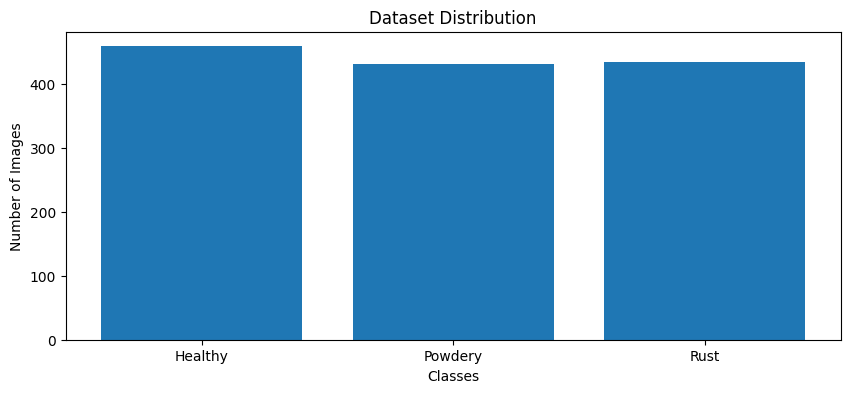

In [7]:
class_names = list(train_generator.class_indices.keys())
labels = train_generator.classes
filepaths = train_generator.filepaths
class_counts = np.bincount(labels)

plt.figure(figsize=(10,4))
plt.bar(class_names, class_counts)
plt.title("Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [8]:
print("Total images:", len(filepaths))
print("Classes:", train_generator.class_indices)
print("Images per class:", class_counts)

Total images: 1322
Classes: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}
Images per class: [458 430 434]


## Sample Images

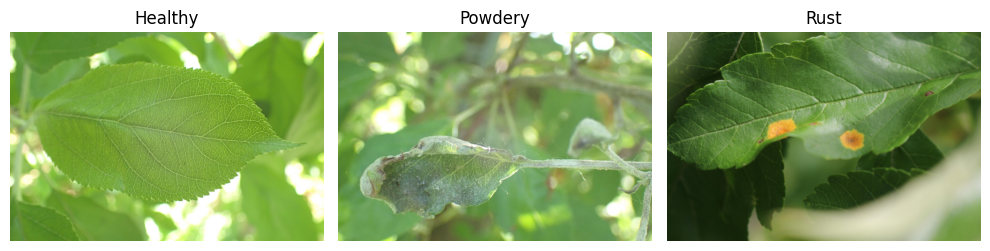

In [9]:
plt.figure(figsize=(10,4))

for i, class_id in enumerate(range(len(class_names))):

    indices = np.where(labels == class_id)[0]
    random_index = random.choice(indices)

    img = cv2.imread(filepaths[random_index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(class_names), i+1)
    plt.imshow(img)
    plt.title(class_names[class_id])
    plt.axis("off")

plt.tight_layout()

# Convolutional Neural Network - Model 1

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

In [11]:
model_1 = Sequential()

# Block 1
model_1.add(Conv2D(32, (3,3), activation='relu',padding = 'same', input_shape = (128,128,3)))
model_1.add(Conv2D(32,(3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
model_1.add(Conv2D(64, (3,3), activation='relu',padding = 'same'))
model_1.add(Conv2D(64,(3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
model_1.add(Conv2D(128, (3,3), activation='relu',padding = 'same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

# Flattening 
model_1.add(Flatten())

# Fully Connected
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.5))

# Output Layer
model_1.add(Dense(3, activation='softmax'))

# Compile
model_1.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

# Model Summary
model_1.summary()

I0000 00:00:1774373248.171747      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774373248.178063      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,334,243 (16.53 MB)

 Trainable params: 4,334,243 (16.53 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
# Fitting the model
history_1 = model_1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    #callbacks=[early_stop]
)

Epoch 1/50


I0000 00:00:1774373260.071271     155 service.cc:152] XLA service 0x41fe6600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774373260.071314     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774373260.071320     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774373260.762290     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-24 17:27:43.824627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:27:43.978458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:27:45.397944: E external/local_xla/xl

 2/42 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3281 - loss: 1.1547 

I0000 00:00:1774373269.403835     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/42 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.3874 - loss: 1.1019

2026-03-24 17:29:01.278404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:29:01.426498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:29:01.689613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:29:01.833406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:29:02.522650: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.4110 - loss: 1.0742 - val_accuracy: 0.5667 - val_loss: 0.8409
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6359 - loss: 0.7668 - val_accuracy: 0.6167 - val_loss: 0.6395
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6417 - loss: 0.7261 - val_accuracy: 0.6000 - val_loss: 0.7980
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7050 - loss: 0.6629 - val_accuracy: 0.7333 - val_loss: 0.6129
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8009 - loss: 0.6211 - val_accuracy: 0.8667 - val_loss: 0.4944
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7234 - loss: 0.7357 - val_accuracy: 0.8000 - val_loss: 0.5260
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8772 - loss: 0.4017 - val_accuracy: 0.8500 - val_loss: 0.4579
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9039 - loss: 0.2853 - val_accuracy: 0.8667 - val_loss: 0.3573
Ep

## Visualizing Train and Validation Accuracy and Loss

In [14]:
loss, accuracy1 = model_1.evaluate(test_generator)
print(f"Test Accuracy: {accuracy1}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9265 - loss: 0.3845
Test Accuracy: 0.9266666769981384


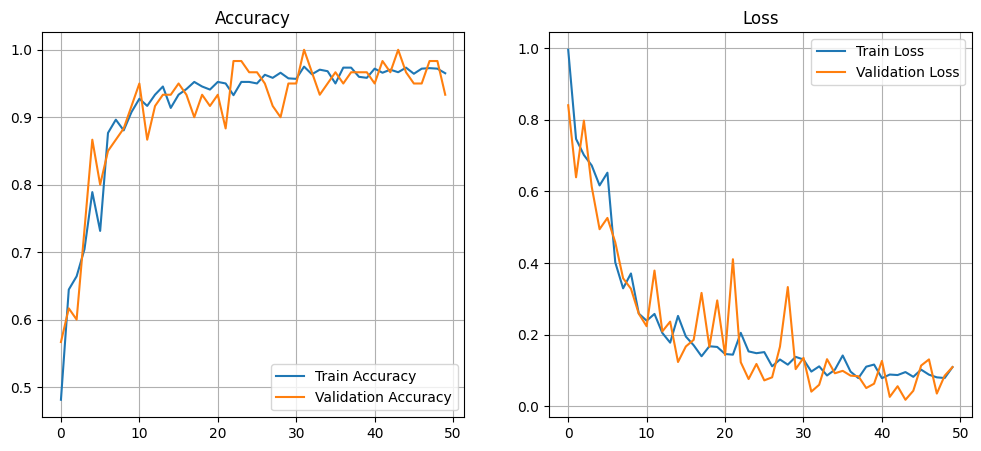

In [15]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.grid(True)
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.grid(True)

plt.show()

## Prediction Using model_1

In [16]:
test_images, test_labels = next(test_generator)
test_predictions = model_1.predict(test_images)

test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

test_class_names = list(test_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


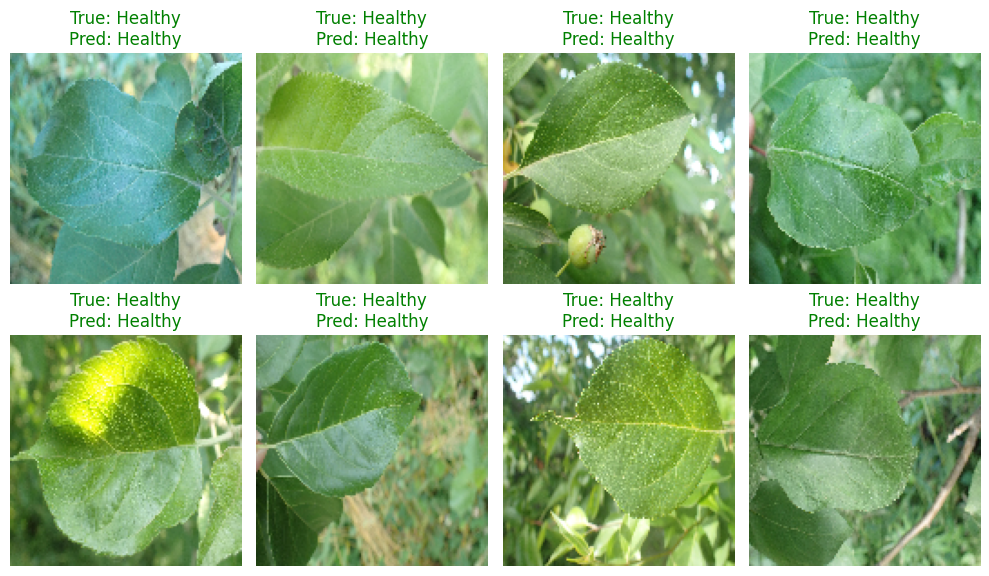

In [17]:
plt.figure(figsize=(10,6))

for i in range(8):   # display 8 test images
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(test_images[i])
    
    true_label = test_class_names[test_true_classes[i]]
    pred_label = test_class_names[test_pred_classes[i]]
    
    color = "green" if true_label == pred_label else "red"
    
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    
    plt.axis('off')

plt.tight_layout()
plt.show()

## Confusion Matrix

In [18]:
# Predict on entire test set
y_pred = model_1.predict(test_generator)

# Convert probabilities → class indices
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


In [19]:
cm = confusion_matrix(y_true, y_pred_classes)

In [20]:
cm

array([[49,  1,  0],
       [ 8, 42,  0],
       [ 2,  0, 48]])

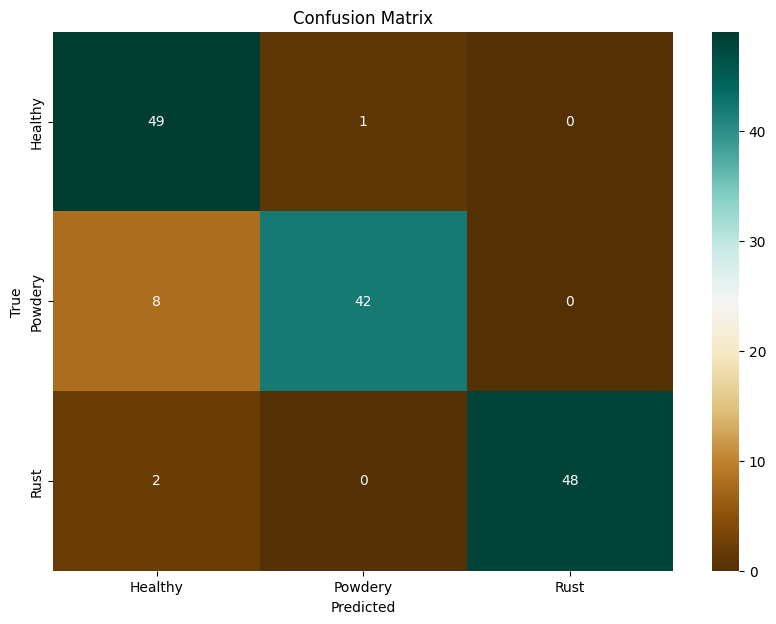

In [21]:
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=class_names,yticklabels=class_names, cmap='BrBG')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### Classification Report

- Classes: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}

In [22]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        50
           1       0.98      0.84      0.90        50
           2       1.00      0.96      0.98        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



In [24]:
model_1.save("model.keras")

In [25]:
import json

class_names = list(train_generator.class_indices.keys())

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [26]:
with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [27]:
import pickle

with open("history_1.pkl", "wb") as f:
    pickle.dump(history_1.history, f)